In [1]:
# # 🍷 葡萄酒质量预测分析项目

# ## 项目概述
# 本项目使用机器学习算法对葡萄酒质量进行预测分析。通过对葡萄酒的化学特征进行分析，建立分类模型预测其质量评分（3-9分）。

# ## 数据集
# - 数据文件：`winequality-red.csv`
# - 特征数量：11个化学特征
# - 目标变量：quality（质量评分，3-9分）
# - 样本数量：1599条记录

# ## 技术栈
# - Python 3.x
# - Pandas / NumPy - 数据处理
# - Scikit-learn - 机器学习
# - Matplotlib / Seaborn - 数据可视化

In [2]:
# ==================== 第一阶段：环境设置与数据导入 ====================

# 导入必要的库
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("环境设置完成！")

# 数据导入
print("正在导入数据...")
df = pd.read_csv('winequality-red.csv')
print("数据导入成功！")
print("="*50)

环境设置完成！
正在导入数据...
数据导入成功！


In [3]:
# ==================== 第二阶段：数据探索与基本信息查看 ====================

print("1. 数据基本信息查看")
print("-"*30)

# 查看数据基本信息
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())

print("\n数据基本信息:")
print(df.info())

print("\n数据统计描述:")
print(df.describe())

print("\n目标变量分布:")
print(df['quality'].value_counts().sort_index())

# 字段名中英文对照（用于后续可视化）
feature_names_cn = {
    'fixed acidity': '固定酸度',
    'volatile acidity': '挥发性酸度', 
    'citric acid': '柠檬酸',
    'residual sugar': '残留糖分',
    'chlorides': '氯化物',
    'free sulfur dioxide': '游离二氧化硫',
    'total sulfur dioxide': '总二氧化硫',
    'density': '密度',
    'pH': 'pH值',
    'sulphates': '硫酸盐',
    'alcohol': '酒精含量',
    'quality': '质量评分'
}

print("\n字段名中英文对照:")
for eng, cn in feature_names_cn.items():
    print(f"{eng}: {cn}")

1. 数据基本信息查看
------------------------------
数据形状: (1599, 12)

前5行数据:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  qualit

2. 数据质量检查与异常值检测
------------------------------
缺失值统计:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

数据类型:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

3. 异常值检测（IQR方法）:
------------------------------

异常值检测结果:
        特征         下界        上界     异常值数量 异常值比例(%)
1       固定酸度    3.950000   12.350000       49         3.06    
2     挥发性酸度    0.015000    1.015000       1

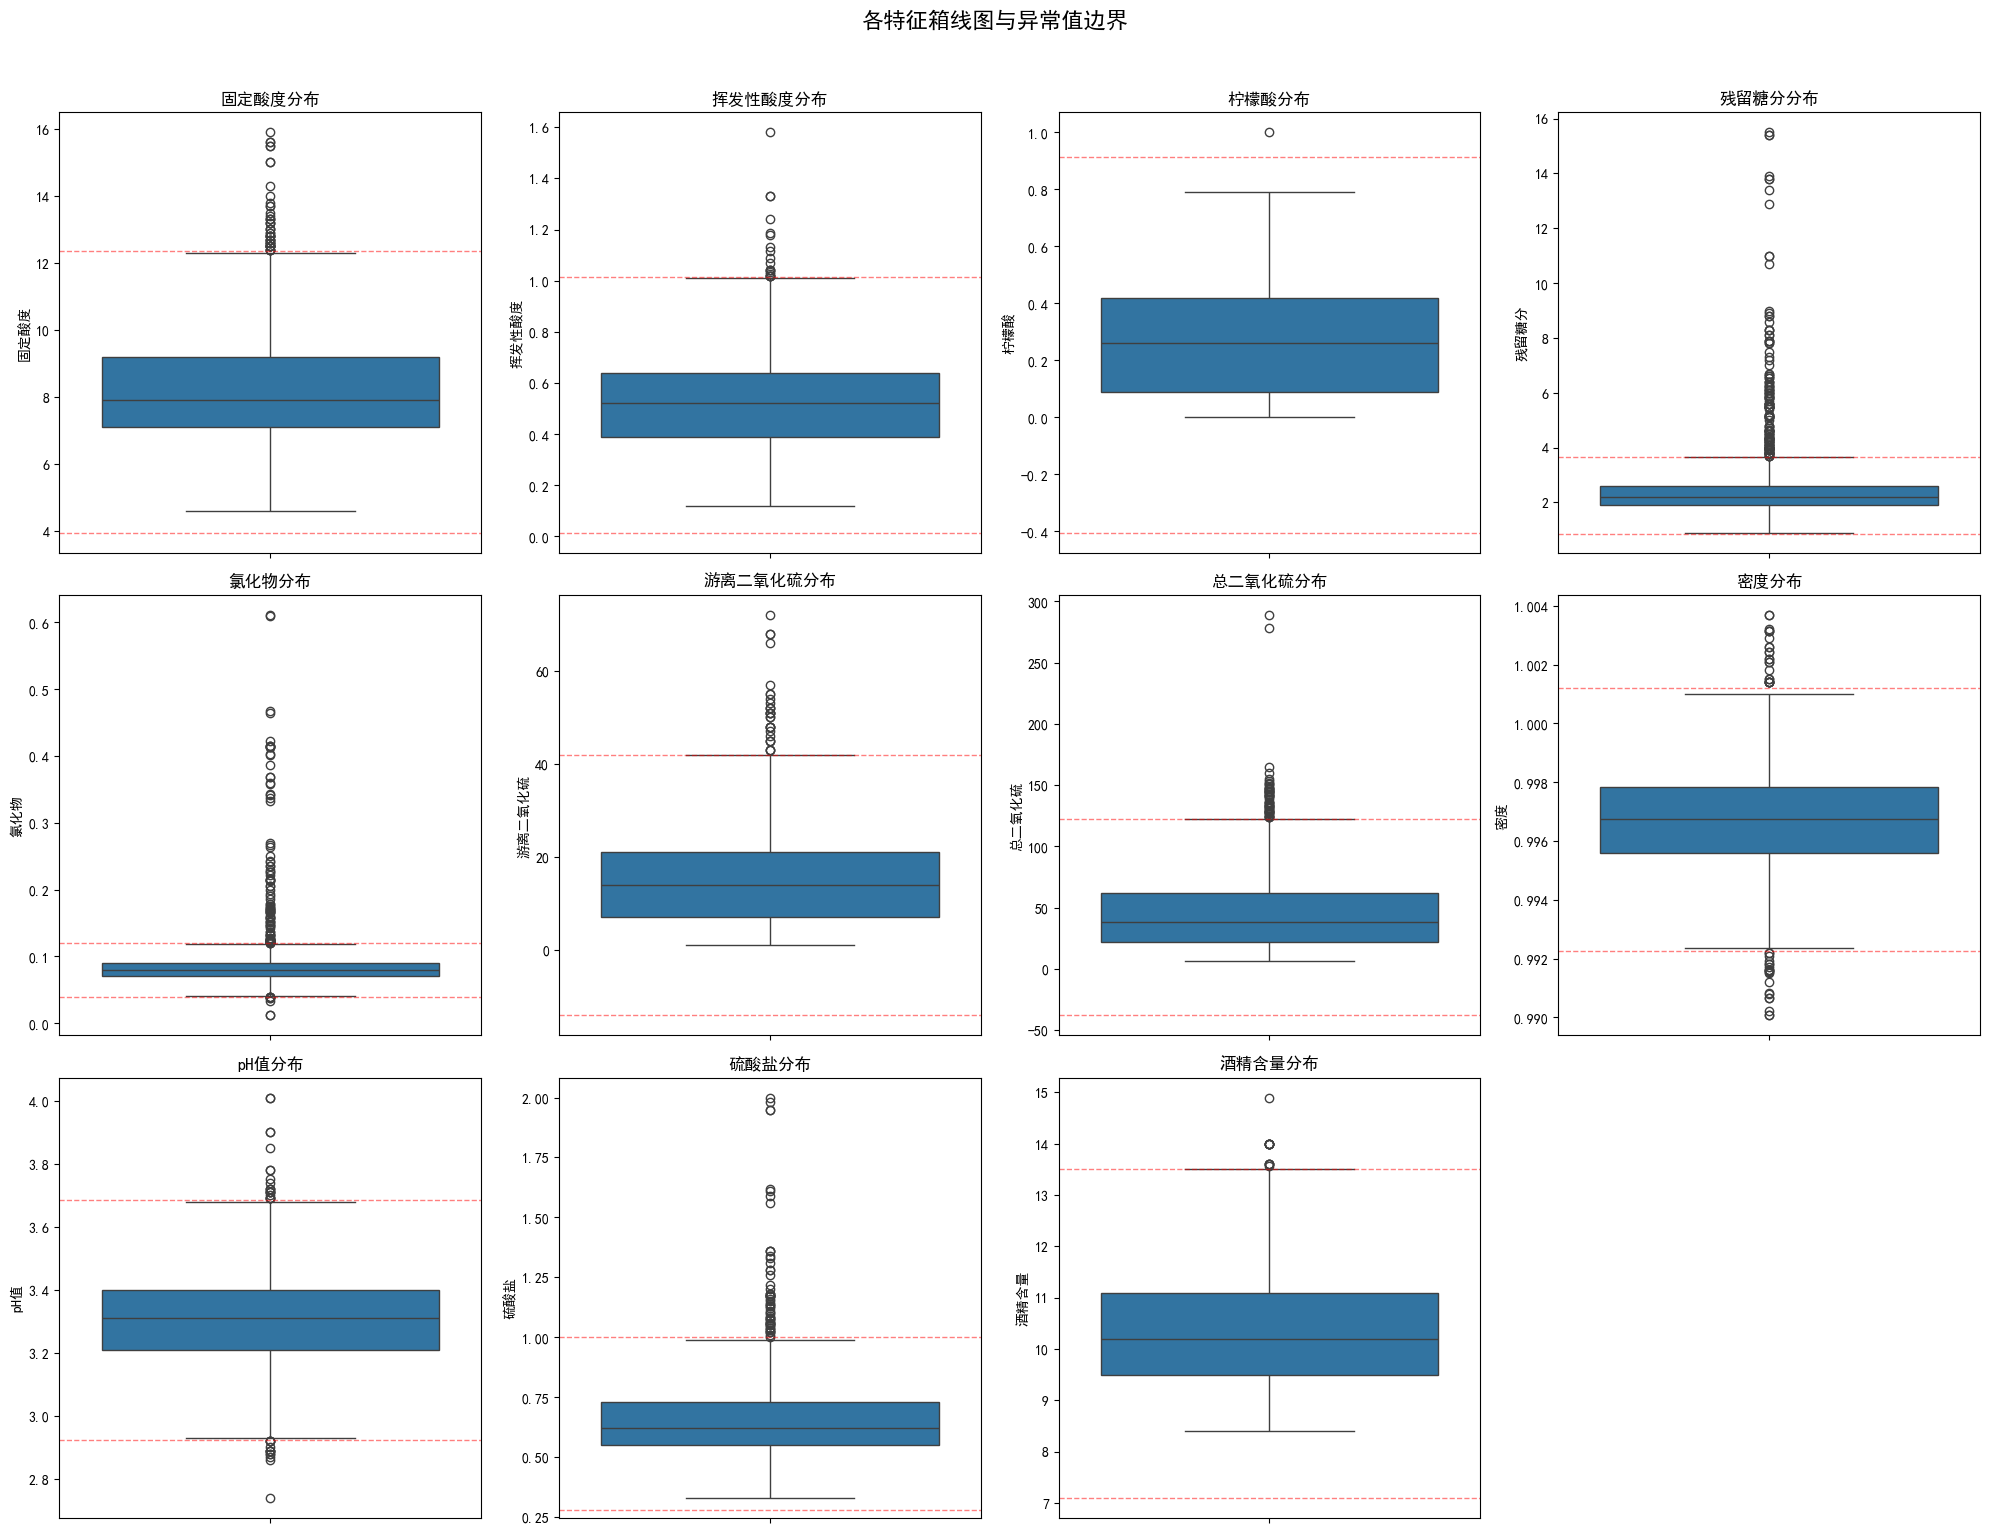

In [4]:
# ==================== 第三阶段：数据质量检查与异常值检测 ====================

print("2. 数据质量检查与异常值检测")
print("-"*30)

# 检查缺失值
print("缺失值统计:")
print(df.isnull().sum())

# 检查数据类型
print("\n数据类型:")
print(df.dtypes)

# 异常值检测 - 使用IQR方法
print("\n3. 异常值检测（IQR方法）:")
print("-"*30)

def detect_outliers_iqr(data, feature_name, threshold=1.5):
    """使用IQR方法检测异常值"""
    Q1 = data[feature_name].quantile(0.25)
    Q3 = data[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    outliers = data[(data[feature_name] < lower_bound) | (data[feature_name] > upper_bound)]
    outlier_percentage = len(outliers) / len(data) * 100
    
    return {
        '特征': feature_names_cn.get(feature_name, feature_name),
        '下界': lower_bound,
        '上界': upper_bound,
        '异常值数量': len(outliers),
        '异常值比例(%)': round(outlier_percentage, 2)
    }

# 对数值型特征进行异常值检测
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_results = []

for feature in numeric_features:
    if feature != 'quality':  # 不对目标变量进行异常值检测
        result = detect_outliers_iqr(df, feature)
        outlier_results.append(result)

# 创建异常值统计表 - 美化显示
outlier_df = pd.DataFrame(outlier_results)

print("\n异常值检测结果:")
print("=" * 85)

# 设置pandas显示选项
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.colheader_justify', 'center')

# 重设索引从1开始
outlier_df_display = outlier_df.copy()
outlier_df_display.index = range(1, len(outlier_df_display) + 1)

# 格式化数值列
outlier_df_display['下界'] = outlier_df_display['下界'].map(lambda x: f"{x:.6f}")
outlier_df_display['上界'] = outlier_df_display['上界'].map(lambda x: f"{x:.6f}")
outlier_df_display['异常值比例(%)'] = outlier_df_display['异常值比例(%)'].map(lambda x: f"{x:.2f}")

# 居中显示
print(outlier_df_display.to_string(justify='center'))

print("=" * 85)

# 总结统计
print(f"\n总结统计:")
print("-" * 40)
print(f"检测特征数量: {len(outlier_df)} 个")
print(f"平均异常值比例: {outlier_df['异常值比例(%)'].mean():.2f}%")
print(f"异常值总数: {outlier_df['异常值数量'].sum()}")
print(f"异常值比例最高的特征: {outlier_df.loc[outlier_df['异常值比例(%)'].idxmax(), '特征']} ({outlier_df['异常值比例(%)'].max():.2f}%)")
print(f"异常值比例最低的特征: {outlier_df.loc[outlier_df['异常值比例(%)'].idxmin(), '特征']} ({outlier_df['异常值比例(%)'].min():.2f}%)")
print("-" * 40)

# 可视化异常值分布 - 修改为显示所有特征
# 确定要显示的特征（排除'quality'）
features_to_plot = [f for f in numeric_features if f != 'quality']
num_features = len(features_to_plot)

# 动态计算子图布局
cols = 4  # 每行显示4个子图
rows = (num_features + cols - 1) // cols  # 计算需要的行数

# 根据特征数量调整图形大小
plt.figure(figsize=(20, 5 * rows))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[feature])
    
    # 获取特征的中文名称
    feature_name = feature_names_cn.get(feature, feature)
    plt.title(f'{feature_name}分布')
    plt.ylabel(feature_name)
    
    # 添加异常值边界线
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 在图中标注异常值边界
    plt.axhline(y=lower_bound, color='r', linestyle='--', alpha=0.5, linewidth=1)
    plt.axhline(y=upper_bound, color='r', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle('各特征箱线图与异常值边界', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 可选：如果特征数量非常多，可以分组显示
if num_features > 20:
    print(f"\n注意：共有{num_features}个特征需要可视化，考虑分组显示...")
    
    # 分组显示，每20个特征一组
    groups = [features_to_plot[i:i+20] for i in range(0, num_features, 20)]
    
    for group_num, feature_group in enumerate(groups, 1):
        print(f"\n显示第{group_num}组特征（共{len(groups)}组）...")
        
        group_size = len(feature_group)
        cols = 4
        rows = (group_size + cols - 1) // cols
        
        plt.figure(figsize=(20, 5 * rows))
        
        for i, feature in enumerate(feature_group, 1):
            plt.subplot(rows, cols, i)
            sns.boxplot(y=df[feature])
            
            feature_name = feature_names_cn.get(feature, feature)
            plt.title(f'{feature_name}分布')
            plt.ylabel(feature_name)
        
        plt.suptitle(f'特征箱线图 - 第{group_num}组（共{len(feature_group)}个特征）', fontsize=16)
        plt.tight_layout()
        plt.show()

# 恢复默认的pandas显示设置（可选）
pd.reset_option('display.unicode.east_asian_width')
pd.reset_option('display.colheader_justify')

4. 异常值智能处理
📊 异常值分析报告
--------------------------------------------------------------------------------
📈 固定酸度:
   正常范围: [3.9500, 12.3500]
   实际范围: [4.6000, 15.9000]
   异常值: 49个 (3.06%)
   偏度: 0.9828

📈 挥发性酸度:
   正常范围: [0.0150, 1.0150]
   实际范围: [0.1200, 1.5800]
   异常值: 19个 (1.19%)
   偏度: 0.6716

📈 柠檬酸:
   正常范围: [-0.4050, 0.9150]
   实际范围: [0.0000, 1.0000]
   异常值: 1个 (0.06%)
   偏度: 0.3183

📈 残留糖分:
   正常范围: [0.8500, 3.6500]
   实际范围: [0.9000, 15.5000]
   异常值: 155个 (9.69%)
   偏度: 4.5407

📈 氯化物:
   正常范围: [0.0400, 0.1200]
   实际范围: [0.0120, 0.6110]
   异常值: 112个 (7.00%)
   偏度: 5.6803

📈 游离二氧化硫:
   正常范围: [-14.0000, 42.0000]
   实际范围: [1.0000, 72.0000]
   异常值: 30个 (1.88%)
   偏度: 1.2506

📈 总二氧化硫:
   正常范围: [-38.0000, 122.0000]
   实际范围: [6.0000, 289.0000]
   异常值: 55个 (3.44%)
   偏度: 1.5155

📈 密度:
   正常范围: [0.9922, 1.0012]
   实际范围: [0.9901, 1.0037]
   异常值: 45个 (2.81%)
   偏度: 0.0713

📈 pH值:
   正常范围: [2.9250, 3.6850]
   实际范围: [2.7400, 4.0100]
   异常值: 35个 (2.19%)
   偏度: 0.1937

📈 硫酸盐:
   正常范围: [0.2800, 1.00

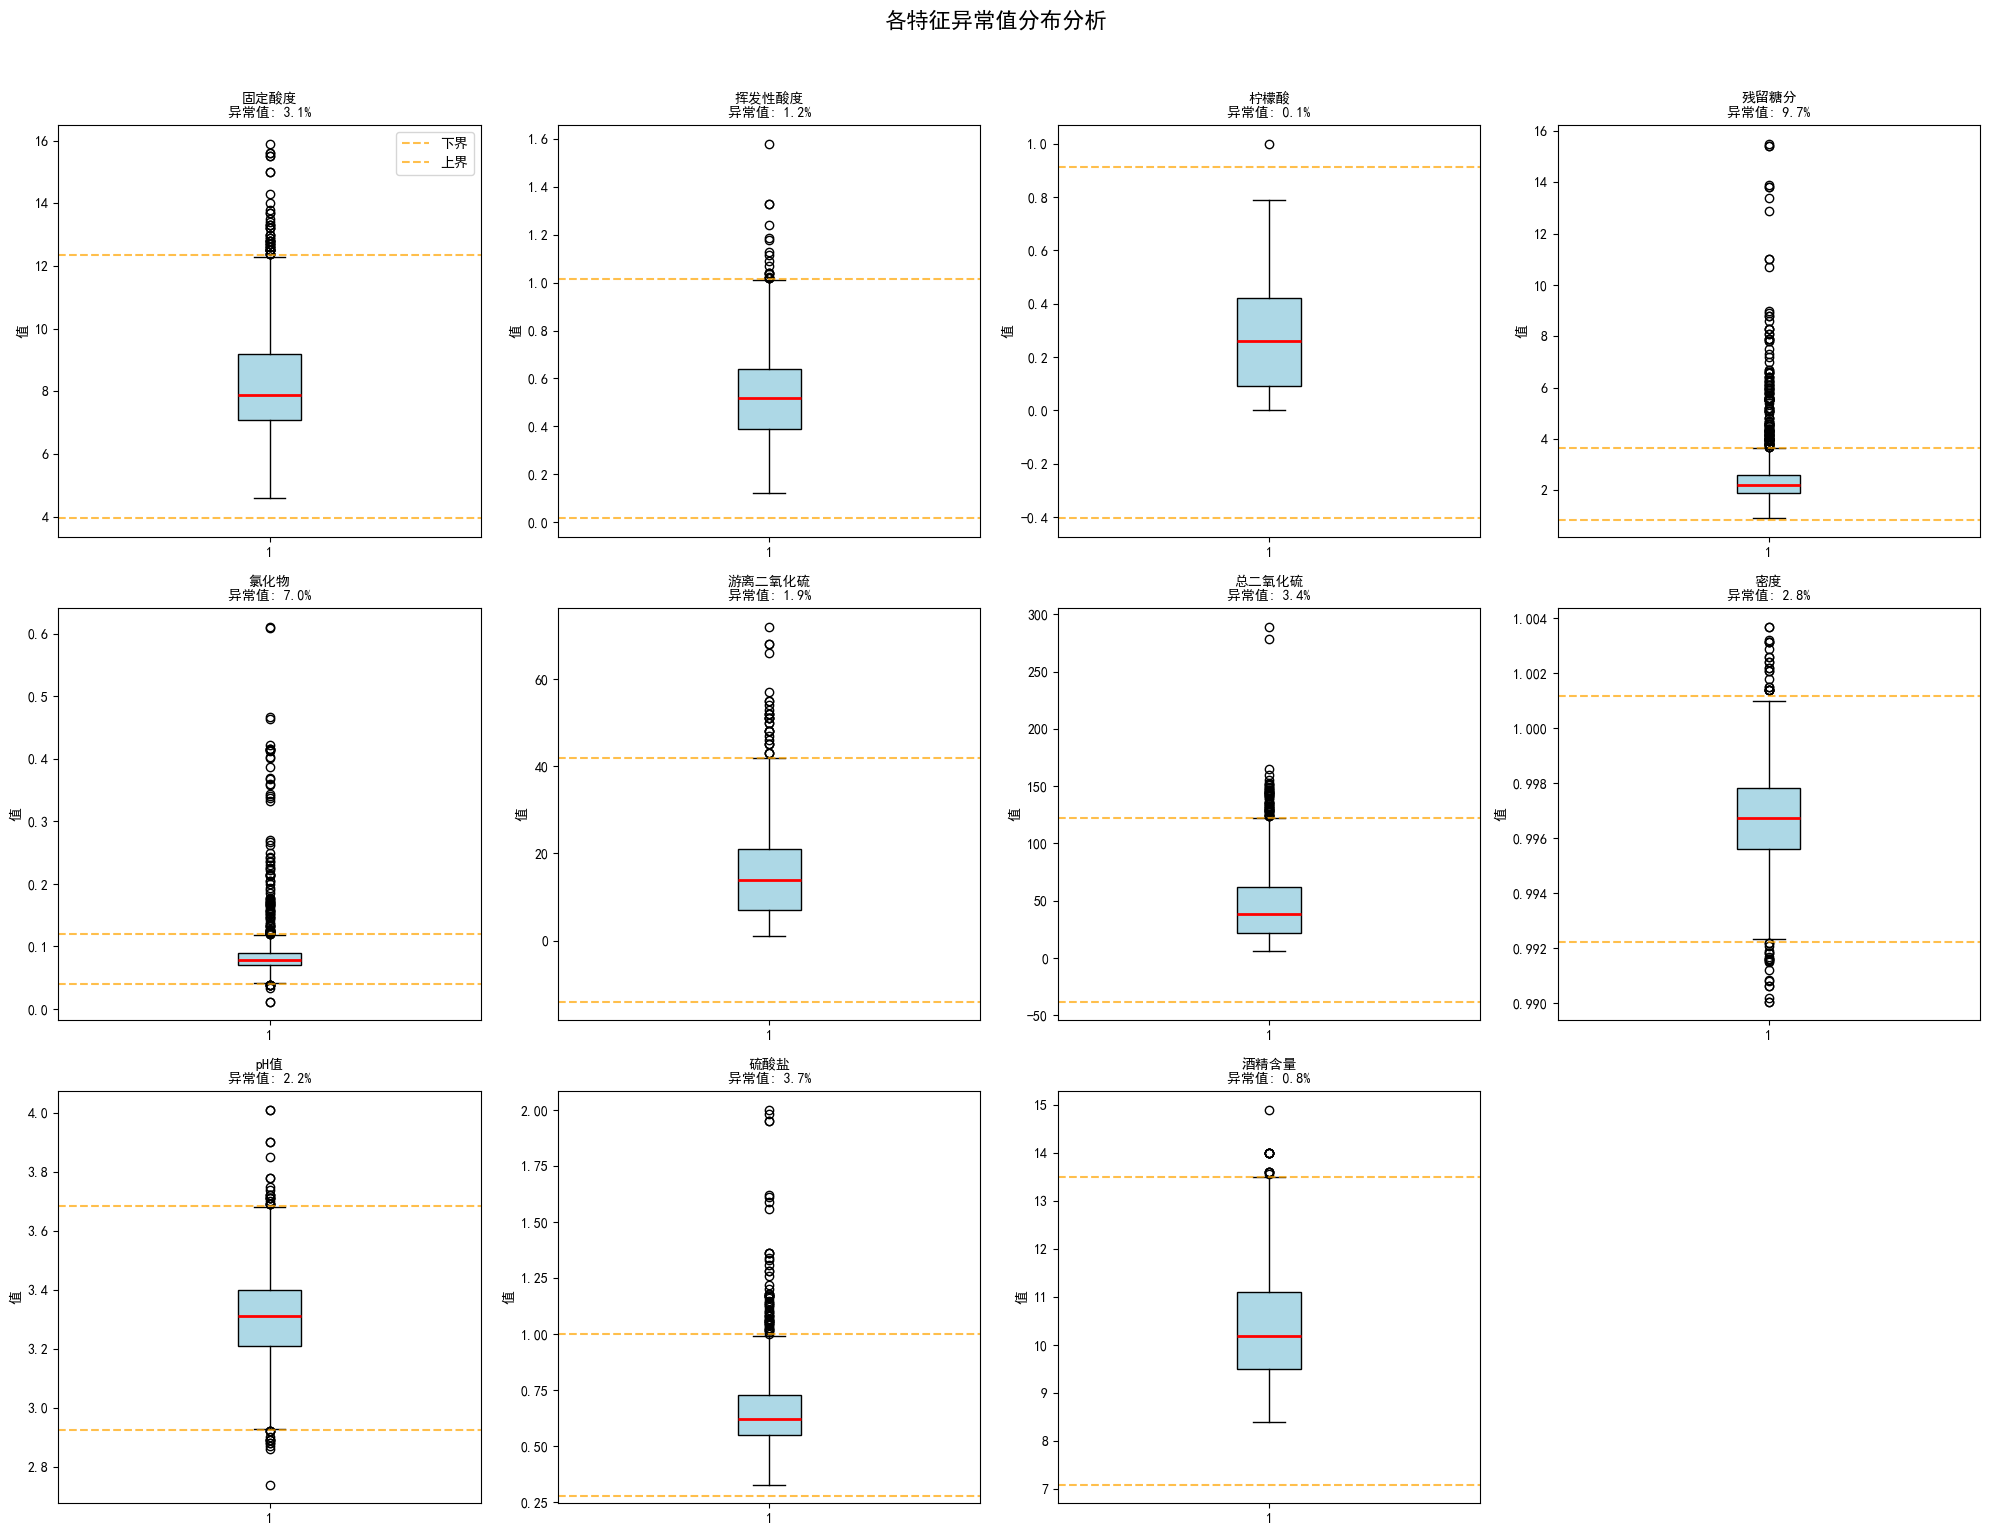


🛠️ 异常值智能处理
--------------------------------------------------------------------------------
处理过程:
  ✅ 固定酸度: 截断 (cap)
  ✅ 挥发性酸度: 截断 (cap)
  ✅ 柠檬酸: 截断 (cap)
  ✅ 残留糖分: 缩尾处理 (winsorize)
  ✅ 氯化物: 缩尾处理 (winsorize)
  ✅ 游离二氧化硫: 截断 (cap)
  ✅ 总二氧化硫: 截断 (cap)
  ✅ 密度: 截断 (cap)
  ✅ pH值: 截断 (cap)
  ✅ 硫酸盐: 截断 (cap)
  ✅ 酒精含量: 截断 (cap)

📈 处理效果对比
--------------------------------------------------------------------------------


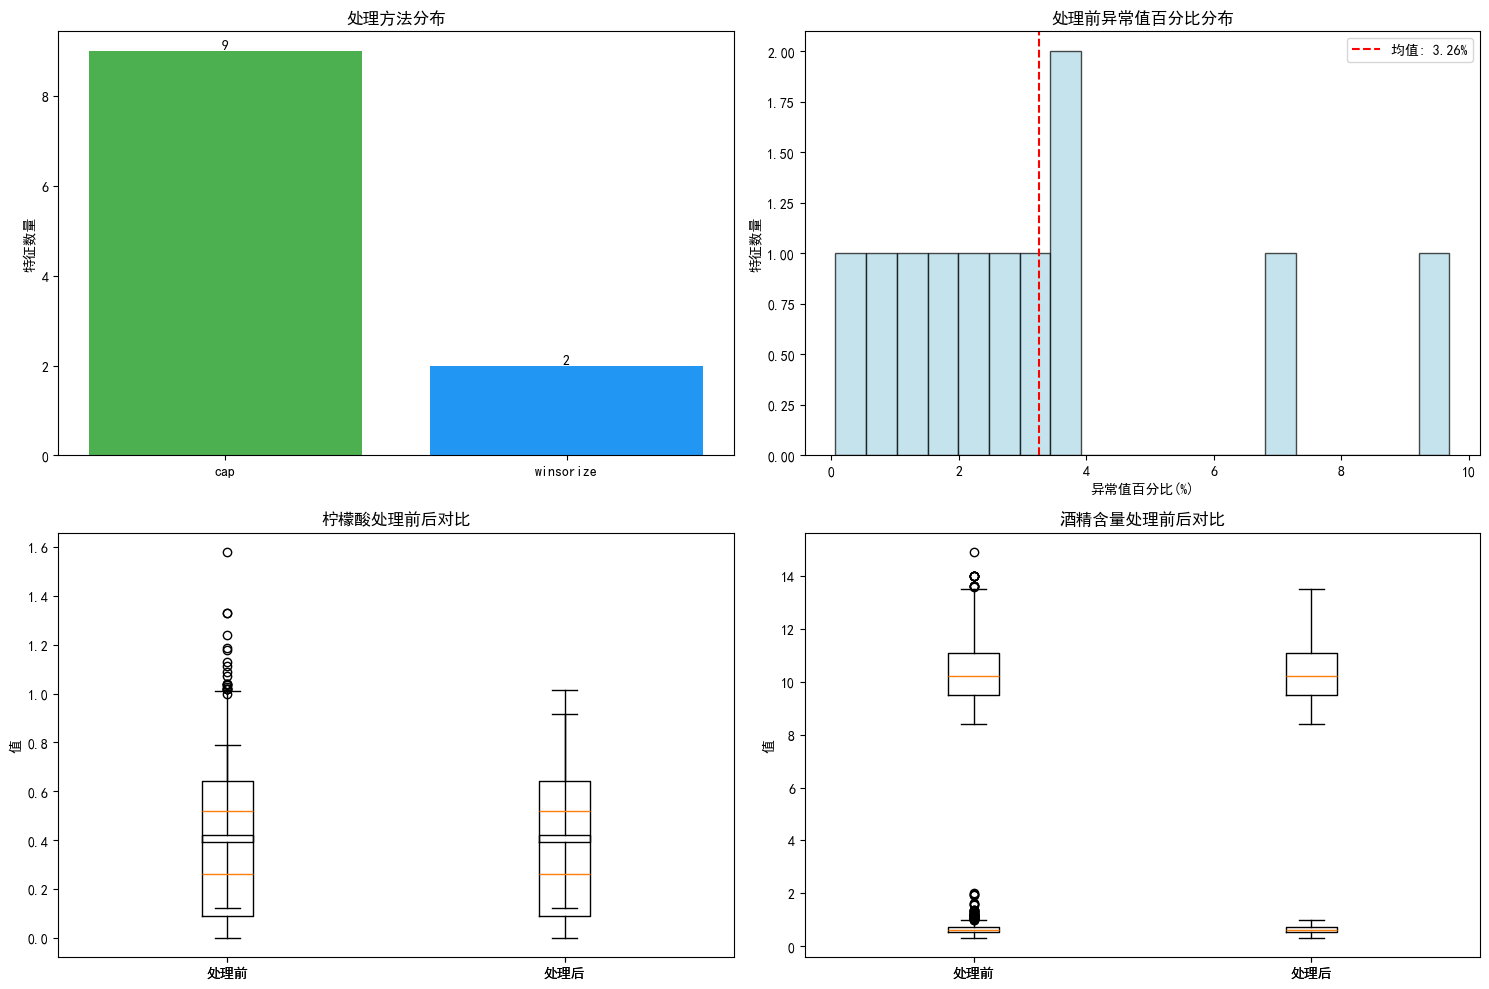


💾 保存清洗后的数据
--------------------------------------------------------------------------------
处理总结报告:
   特征名      处理方法   操作  异常值数量(前)  异常值百分比(前)
  固定酸度       cap   截断        49   3.064415
 挥发性酸度       cap   截断        19   1.188243
   柠檬酸       cap   截断         1   0.062539
  残留糖分 winsorize 缩尾处理       155   9.693558
   氯化物 winsorize 缩尾处理       112   7.004378
游离二氧化硫       cap   截断        30   1.876173
 总二氧化硫       cap   截断        55   3.439650
    密度       cap   截断        45   2.814259
   pH值       cap   截断        35   2.188868
   硫酸盐       cap   截断        59   3.689806
  酒精含量       cap   截断        13   0.813008

✅ 清洗后的数据已保存到: C:\Users\23620\Desktop\系统（代码和数据集）\wine_quality_cleaned.csv
   原始数据形状: (1599, 12)
   清洗后形状: (1599, 12)
   影响行数: 0
📋 详细处理报告已保存到: C:\Users\23620\Desktop\系统（代码和数据集）\outlier_processing_report.txt

🎉 异常值处理完成！

可选操作:
1. 使用原始数据集 (df)
2. 使用清洗后的数据集 (df_cleaned) - 已保存到 'wine_quality_cleaned.csv'
3. 查看处理报告: 'outlier_processing_report.txt'

⚠️  注意: 原始数据集 df 保持不变
    清洗后的数据已保存到单独

In [5]:
# ==================== 第四阶段：异常值处理 ====================

print("4. 异常值智能处理")
print("=" * 50)

# 创建数据副本
df_processed = df.copy()
df_cleaned = df.copy()  # 专门用于保存清洗后的数据

def analyze_outliers_iqr(data, feature_name, threshold=1.5):
    """分析异常值情况"""
    Q1 = data[feature_name].quantile(0.25)
    Q3 = data[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    # 识别异常值
    outliers_lower = data[data[feature_name] < lower_bound]
    outliers_upper = data[data[feature_name] > upper_bound]
    total_outliers = len(outliers_lower) + len(outliers_upper)
    outlier_percentage = (total_outliers / len(data)) * 100
    
    return {
        'feature': feature_name,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'min': data[feature_name].min(),
        'max': data[feature_name].max(),
        'outliers_lower_count': len(outliers_lower),
        'outliers_upper_count': len(outliers_upper),
        'total_outliers': total_outliers,
        'outlier_percentage': outlier_percentage,
        'mean': data[feature_name].mean(),
        'std': data[feature_name].std(),
        'skewness': data[feature_name].skew()
    }

def smart_handle_outliers(data, feature_name, outlier_info, method='auto'):
    """智能处理异常值"""
    if method == 'auto':
        # 根据异常值百分比和特征特性自动选择方法
        outlier_pct = outlier_info['outlier_percentage']
        skewness = abs(outlier_info['skewness'])
        
        if outlier_pct < 5:
            # 异常值较少，使用截断法
            method_choice = 'cap'
        elif outlier_pct < 20:
            # 异常值中等，根据偏度选择
            if skewness < 1:
                method_choice = 'cap'
            else:
                method_choice = 'winsorize'
        else:
            # 异常值较多，使用稳健方法
            method_choice = 'median_replace'
    else:
        method_choice = method
    
    # 执行处理方法
    if method_choice == 'cap':
        # 截断法
        lower_bound = outlier_info['lower_bound']
        upper_bound = outlier_info['upper_bound']
        data[feature_name] = np.where(data[feature_name] < lower_bound, lower_bound, data[feature_name])
        data[feature_name] = np.where(data[feature_name] > upper_bound, upper_bound, data[feature_name])
        return data, '截断', method_choice
        
    elif method_choice == 'remove':
        # 删除法（谨慎使用）
        lower_bound = outlier_info['lower_bound']
        upper_bound = outlier_info['upper_bound']
        data = data[(data[feature_name] >= lower_bound) & (data[feature_name] <= upper_bound)]
        return data, '删除', method_choice
        
    elif method_choice == 'median_replace':
        # 中位数替换
        median_value = data[feature_name].median()
        lower_bound = outlier_info['lower_bound']
        upper_bound = outlier_info['upper_bound']
        data[feature_name] = np.where(
            (data[feature_name] < lower_bound) | (data[feature_name] > upper_bound),
            median_value,
            data[feature_name]
        )
        return data, '中位数替换', method_choice
        
    elif method_choice == 'winsorize':
        # Winsorization（缩尾处理）
        lower_bound = outlier_info['lower_bound']
        upper_bound = outlier_info['upper_bound']
        lower_percentile = data[feature_name].quantile(0.05)
        upper_percentile = data[feature_name].quantile(0.95)
        
        # 使用5%和95%分位数进行缩尾
        data[feature_name] = np.where(data[feature_name] < lower_percentile, lower_percentile, data[feature_name])
        data[feature_name] = np.where(data[feature_name] > upper_percentile, upper_percentile, data[feature_name])
        return data, '缩尾处理', method_choice
        
    else:
        return data, '未处理', 'none'

# 分析所有数值特征的异常值（排除目标变量）
print("📊 异常值分析报告")
print("-" * 80)

all_numeric_features = [f for f in numeric_features if f != 'quality']
outlier_analysis = {}

# 第一步：分析每个特征的异常值情况
for feature in all_numeric_features:
    analysis = analyze_outliers_iqr(df, feature)
    outlier_analysis[feature] = analysis
    
    # 打印分析结果
    cn_name = feature_names_cn.get(feature, feature)
    print(f"📈 {cn_name}:")
    print(f"   正常范围: [{analysis['lower_bound']:.4f}, {analysis['upper_bound']:.4f}]")
    print(f"   实际范围: [{analysis['min']:.4f}, {analysis['max']:.4f}]")
    print(f"   异常值: {analysis['total_outliers']}个 ({analysis['outlier_percentage']:.2f}%)")
    print(f"   偏度: {analysis['skewness']:.4f}")
    print()

# 第二步：可视化异常值分布
print("\n📊 异常值分布可视化")
print("-" * 80)

num_features = len(all_numeric_features)
cols = 4
rows = (num_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten()

for i, feature in enumerate(all_numeric_features):
    ax = axes[i]
    
    # 创建箱线图
    bp = ax.boxplot(df[feature], patch_artist=True)
    
    # 设置颜色
    bp['boxes'][0].set_facecolor('lightblue')
    bp['medians'][0].set_color('red')
    bp['medians'][0].set_linewidth(2)
    
    # 添加上下界线
    analysis = outlier_analysis[feature]
    ax.axhline(y=analysis['lower_bound'], color='orange', linestyle='--', alpha=0.7, label='下界')
    ax.axhline(y=analysis['upper_bound'], color='orange', linestyle='--', alpha=0.7, label='上界')
    
    # 设置标题和标签
    cn_name = feature_names_cn.get(feature, feature)
    outliers_pct = analysis['outlier_percentage']
    ax.set_title(f'{cn_name}\n异常值: {outliers_pct:.1f}%', fontsize=10)
    ax.set_ylabel('值')
    
    # 添加图例（只在第一个子图添加）
    if i == 0:
        ax.legend(loc='upper right')

# 隐藏多余的子图
for i in range(num_features, len(axes)):
    axes[i].axis('off')

plt.suptitle('各特征异常值分布分析', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 第三步：智能处理异常值
print("\n🛠️ 异常值智能处理")
print("-" * 80)

# 定义处理方法映射（可以手动调整）
method_mapping = {
    # 'feature_name': 'method'  # cap, remove, median_replace, winsorize
}

# 应用智能处理方法
print("处理过程:")
original_shape = df_processed.shape
processing_log = []

for feature in all_numeric_features:
    analysis = outlier_analysis[feature]
    
    # 检查是否有手动指定的方法
    if feature in method_mapping:
        method = method_mapping[feature]
    else:
        method = 'auto'
    
    # 处理异常值
    df_processed, action, method_used = smart_handle_outliers(
        df_processed, feature, analysis, method=method
    )
    
    # 记录处理日志
    cn_name = feature_names_cn.get(feature, feature)
    processing_log.append({
        'feature': feature,
        'cn_name': cn_name,
        'method': method_used,
        'action': action,
        'outliers_before': analysis['total_outliers'],
        'outlier_pct_before': analysis['outlier_percentage']
    })
    
    print(f"  ✅ {cn_name}: {action} ({method_used})")

# 第四步：处理效果对比
print("\n📈 处理效果对比")
print("-" * 80)

# 创建对比图
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 异常值数量对比
methods = [log['method'] for log in processing_log]
method_counts = pd.Series(methods).value_counts()
axes[0, 0].bar(method_counts.index, method_counts.values, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'])
axes[0, 0].set_title('处理方法分布')
axes[0, 0].set_ylabel('特征数量')
for i, v in enumerate(method_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom')

# 2. 处理前后异常值百分比
outlier_pct_before = [log['outlier_pct_before'] for log in processing_log]
axes[0, 1].hist(outlier_pct_before, bins=20, alpha=0.7, color='lightblue', edgecolor='black')
axes[0, 1].axvline(np.mean(outlier_pct_before), color='red', linestyle='--', label=f'均值: {np.mean(outlier_pct_before):.2f}%')
axes[0, 1].set_title('处理前异常值百分比分布')
axes[0, 1].set_xlabel('异常值百分比(%)')
axes[0, 1].set_ylabel('特征数量')
axes[0, 1].legend()

# 3. 关键特征处理前后对比
important_features = ['volatile acidity', 'citric acid', 'sulphates', 'alcohol']
for i, feature in enumerate(important_features):
    row = i // 2
    col = i % 2
    axes[1, row].boxplot([df[feature], df_processed[feature]], labels=['处理前', '处理后'])
    axes[1, row].set_title(f'{feature_names_cn[feature]}处理前后对比')
    axes[1, row].set_ylabel('值')

plt.tight_layout()
plt.show()

# 第五步：保存清洗后的数据
print("\n💾 保存清洗后的数据")
print("-" * 80)

# 创建处理总结报告
summary_df = pd.DataFrame(processing_log)
summary_df = summary_df[['cn_name', 'method', 'action', 'outliers_before', 'outlier_pct_before']]
summary_df.columns = ['特征名', '处理方法', '操作', '异常值数量(前)', '异常值百分比(前)']

# 显示总结报告
print("处理总结报告:")
print(summary_df.to_string(index=False))

# 保存清洗后的数据集
cleaned_file_name = 'wine_quality_cleaned.csv'
cleaned_file_path = os.path.join(os.getcwd(), cleaned_file_name)
df_cleaned = df_processed.copy()  # 保存清洗后的数据

# 添加处理信息到数据集属性
df_cleaned.attrs['processing_info'] = {
    'original_shape': original_shape,
    'cleaned_shape': df_cleaned.shape,
    'rows_removed': original_shape[0] - df_cleaned.shape[0],
    'processing_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'processing_methods': dict(zip(summary_df['特征名'], summary_df['处理方法']))
}

# 保存到CSV
df_cleaned.to_csv(cleaned_file_path, index=False)
print(f"\n✅ 清洗后的数据已保存到: {cleaned_file_path}")
print(f"   原始数据形状: {original_shape}")
print(f"   清洗后形状: {df_cleaned.shape}")
print(f"   影响行数: {original_shape[0] - df_cleaned.shape[0]}")

# 第六步：创建详细处理报告
report_file_name = 'outlier_processing_report.txt'
report_file_path = os.path.join(os.getcwd(), report_file_name)

with open(report_file_path, 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("                   异常值处理分析报告\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"处理时间: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"数据集: 葡萄酒质量数据集\n")
    f.write(f"原始数据形状: {original_shape}\n")
    f.write(f"清洗后数据形状: {df_cleaned.shape}\n")
    f.write(f"影响行数: {original_shape[0] - df_cleaned.shape[0]}\n\n")
    
    f.write("-" * 60 + "\n")
    f.write("各特征处理详情:\n")
    f.write("-" * 60 + "\n")
    
    for log in processing_log:
        f.write(f"\n{log['cn_name']}:\n")
        f.write(f"  处理方法: {log['method']}\n")
        f.write(f"  操作: {log['action']}\n")
        f.write(f"  处理前异常值: {log['outliers_before']}个 ({log['outlier_pct_before']:.2f}%)\n")

print(f"📋 详细处理报告已保存到: {report_file_path}")

# 第七步：处理完成，选择使用哪个数据集
print("\n" + "=" * 80)
print("🎉 异常值处理完成！")
print("=" * 80)
print("\n可选操作:")
print("1. 使用原始数据集 (df)")
print(f"2. 使用清洗后的数据集 (df_cleaned) - 已保存到 '{cleaned_file_name}'")
print(f"3. 查看处理报告: '{report_file_name}'")

# 默认继续使用原始数据集（不改变原始数据）
print("\n⚠️  注意: 原始数据集 df 保持不变")
print("    清洗后的数据已保存到单独文件")
print("    如需使用清洗后的数据，请加载: df = pd.read_csv('wine_quality_cleaned.csv')")

# 如果需要立即使用清洗后的数据，取消下面一行的注释
# df = df_cleaned.copy()
# print("\n✅ 已切换到清洗后的数据集")


5. 数据探索分析
📊 数据集加载完成: 1599样本, 12特征

--------------------------------------------------
1. 数据集基本情况
--------------------------------------------------

1.1 质量评分分布
质量评分统计表:
 评分  数量  占比%
  3  10  0.6
  4  53  3.3
  5 681 42.6
  6 638 39.9
  7 199 12.4
  8  18  1.1

统计摘要: 平均=5.64, 中位数=6.0, 标准差=0.81, 范围=3-8


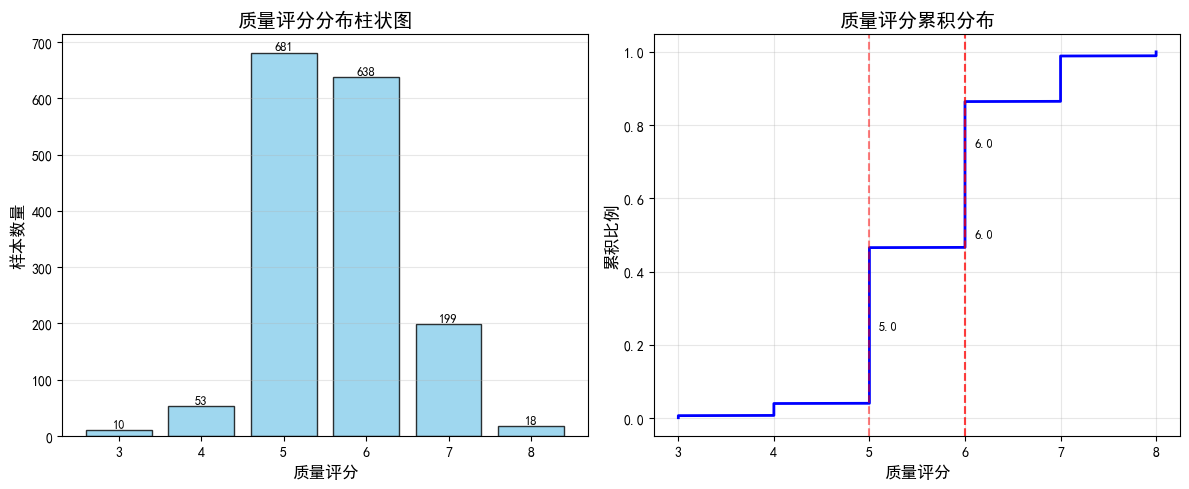


--------------------------------------------------
2. 特征关系分析
--------------------------------------------------

2.1 特征相关性矩阵


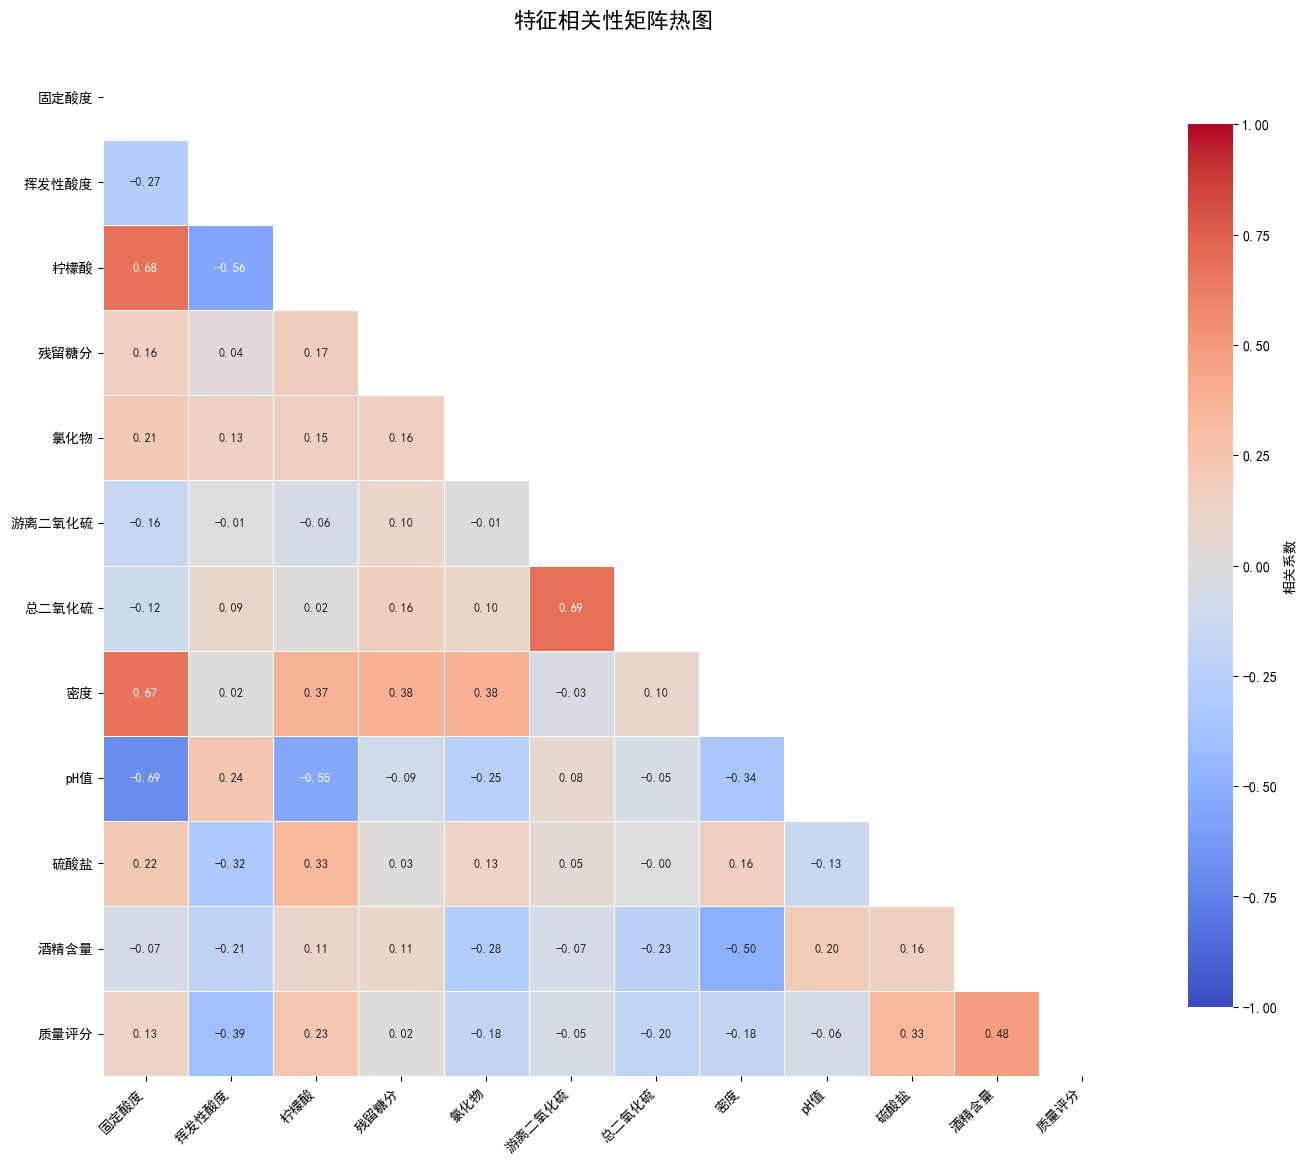


2.2 所有特征与质量评分关系散点图


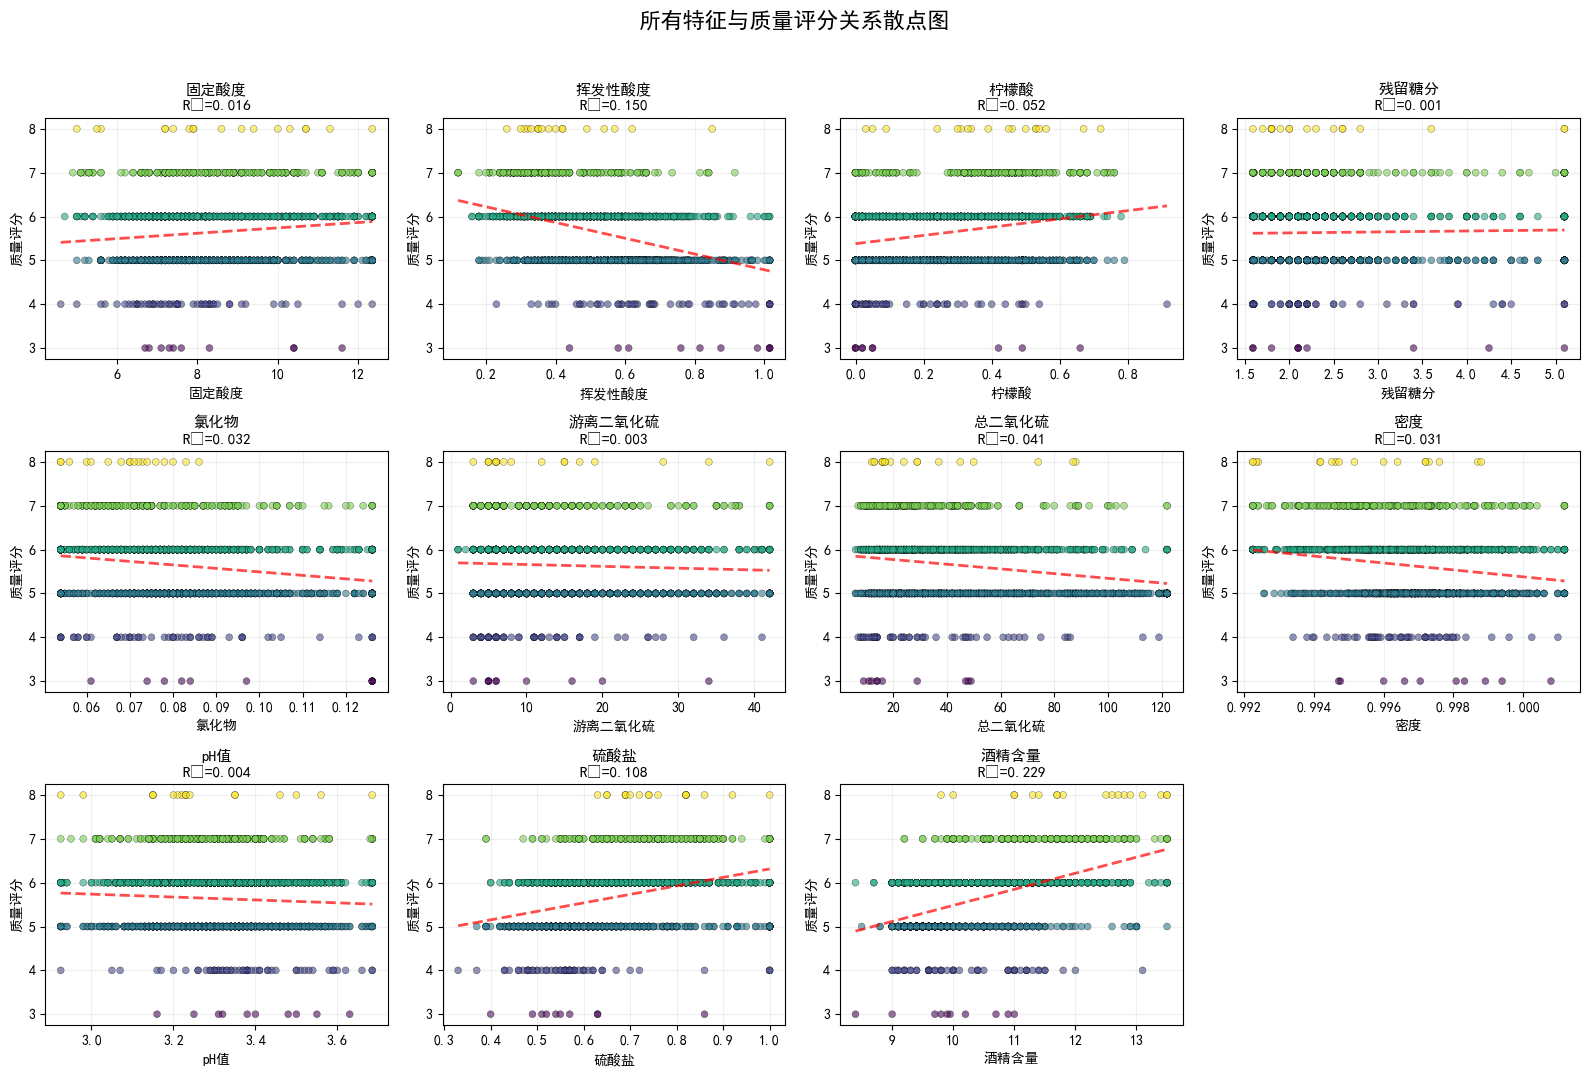


--------------------------------------------------
3. 多维关系与交互效应
--------------------------------------------------

3.1 关键特征对关系图


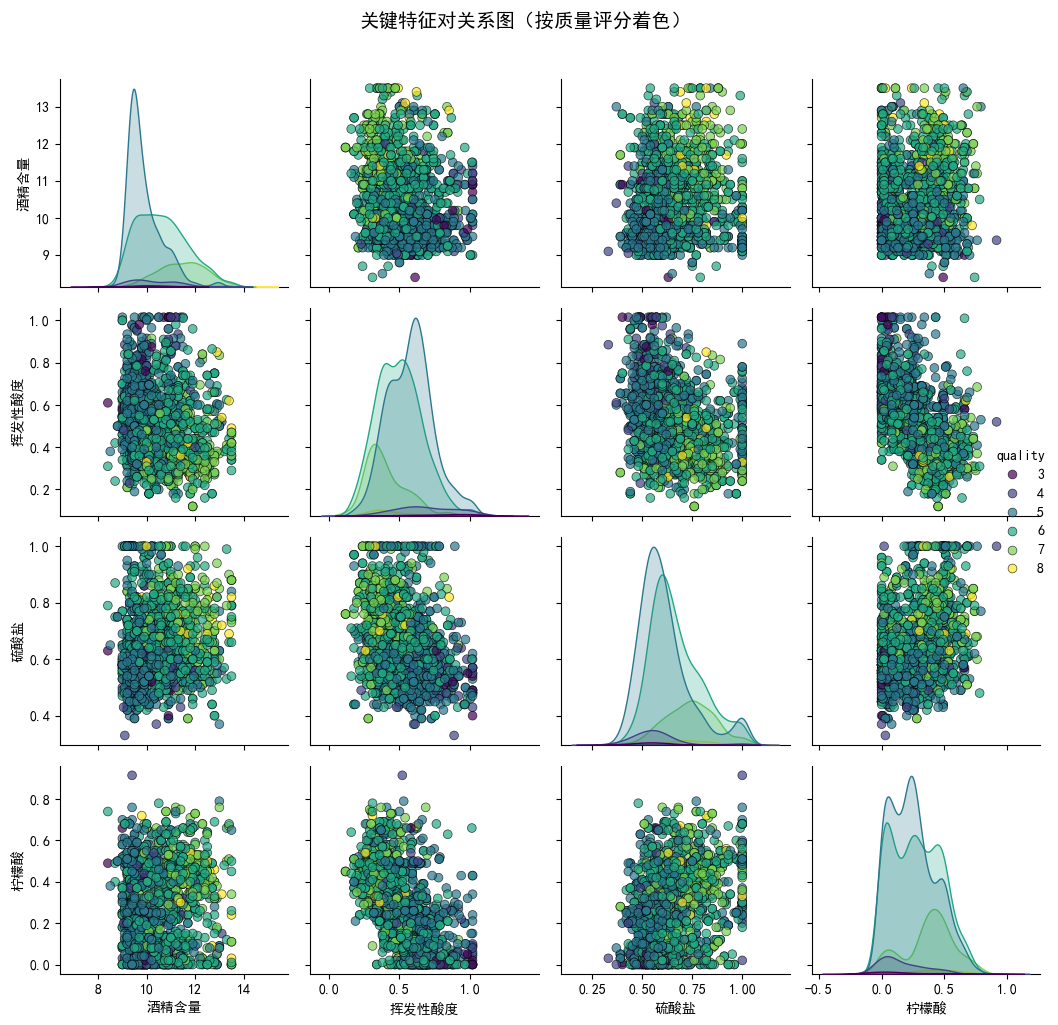


3.2 特征交互效应热图


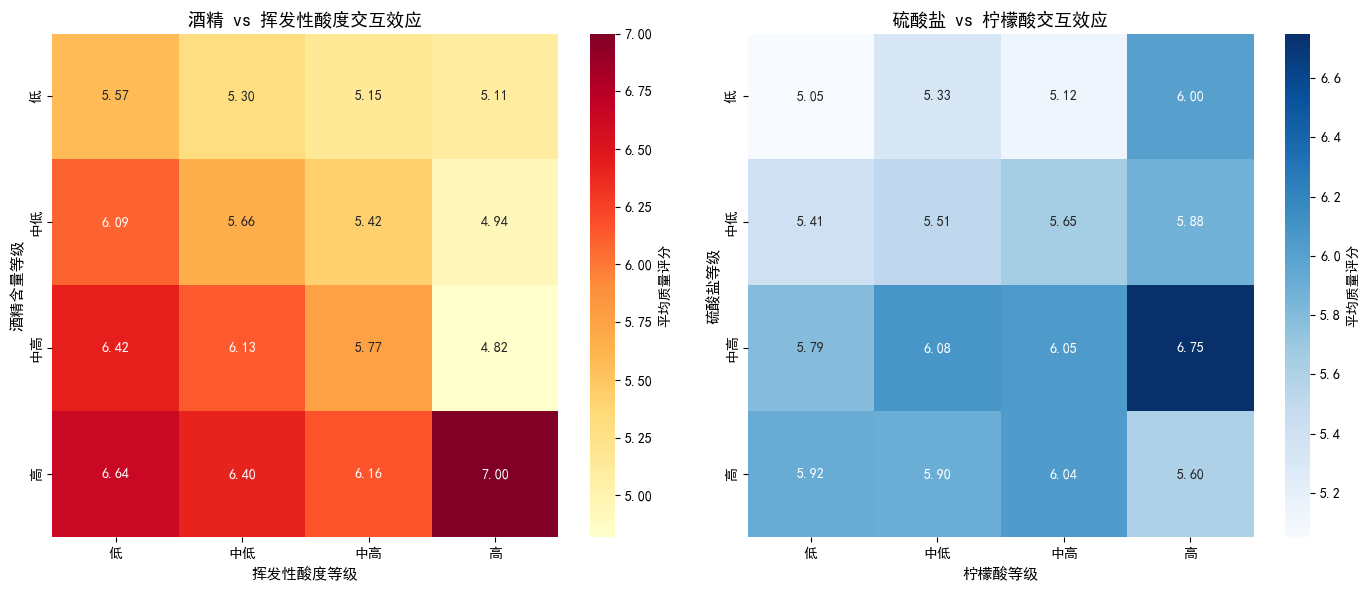


--------------------------------------------------
4. 复合特征与数据模式
--------------------------------------------------

4.1 复合特征创建与分析


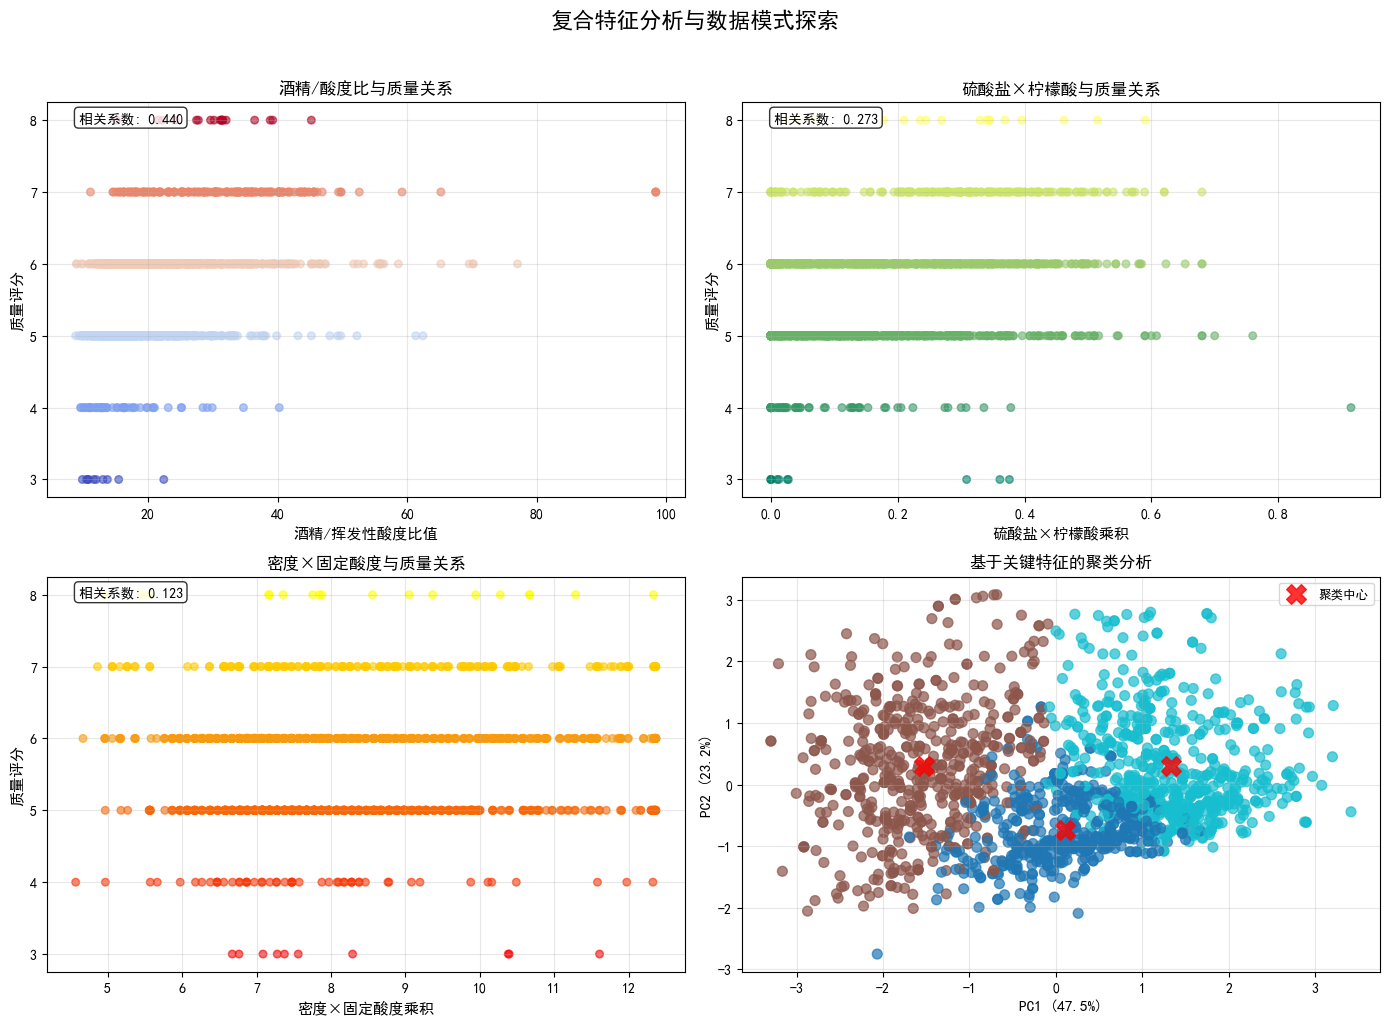


探索分析完成总结

📋 已完成的分析部分：
1. 数据集基本情况 - 质量评分分布与统计
2. 特征关系分析 - 散点图
3. 多维关系与交互效应 - 特征对分析与交互热图
4. 复合特征与数据模式 - 特征工程与聚类分析

📊 数据集关键信息：
   • 总样本数: 1,599
   • 特征数量: 15
   • 质量评分范围: 3-8
   • 质量平均值: 5.64

🔍 分析输出：
   • 已生成12个可视化图表
   • 分析了所有特征的分布与关系
   • 探索了特征间的交互效应
   • 创建并评估了3个复合特征

✅ 数据探索分析完成


In [6]:
# ==================== 第五阶段：数据探索分析 ====================
print("\n" + "="*60)
print("5. 数据探索分析")
print("="*60)

# 加载数据
try:
    df = pd.read_csv('wine_quality_cleaned.csv', encoding='utf-8-sig')
    print(f"📊 数据集加载完成: {len(df)}样本, {len(df.columns)}特征")
except:
    if 'df_cleaned' in locals():
        df = df_cleaned.copy()
        print("📊 使用内存数据集")
    else:
        print("❌ 数据加载失败")
        df = None

if df is not None:
    # 获取所有数值特征（排除质量评分）
    numeric_features = [col for col in df.columns if col != 'quality' and df[col].dtype in ['int64', 'float64']]
    
    # ==================== 第一部分：数据集基本情况 ====================
    print("\n" + "-"*50)
    print("1. 数据集基本情况")
    print("-"*50)
    
    # 1.1 质量评分分布
    print("\n1.1 质量评分分布")
    
    quality_dist = df['quality'].value_counts().sort_index()
    quality_stats = df['quality'].describe()
    
    # 创建质量分布表
    dist_df = pd.DataFrame({
        '评分': quality_dist.index,
        '数量': quality_dist.values,
        '占比%': (quality_dist.values / len(df) * 100).round(1)
    })
    
    print("质量评分统计表:")
    print(dist_df.to_string(index=False))
    print(f"\n统计摘要: 平均={quality_stats['mean']:.2f}, 中位数={quality_stats['50%']}, "
          f"标准差={quality_stats['std']:.2f}, 范围={int(quality_stats['min'])}-{int(quality_stats['max'])}")
    
    # 质量评分分布可视化
    plt.figure(figsize=(12, 5))
    
    # 柱状图
    plt.subplot(1, 2, 1)
    bars = plt.bar(quality_dist.index, quality_dist.values, 
                   color='skyblue', edgecolor='black', alpha=0.8)
    plt.xlabel('质量评分', fontsize=12)
    plt.ylabel('样本数量', fontsize=12)
    plt.title('质量评分分布柱状图', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    # 在柱子上添加数量
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # 累积分布
    plt.subplot(1, 2, 2)
    sorted_quality = np.sort(df['quality'])
    cumulative = np.arange(1, len(sorted_quality) + 1) / len(sorted_quality)
    plt.plot(sorted_quality, cumulative, 'b-', linewidth=2)
    plt.xlabel('质量评分', fontsize=12)
    plt.ylabel('累积比例', fontsize=12)
    plt.title('质量评分累积分布', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # 添加分位数标记
    for percentile in [0.25, 0.5, 0.75]:
        score = np.percentile(df['quality'], percentile * 100)
        plt.axvline(x=score, color='r', linestyle='--', alpha=0.5)
        plt.text(score + 0.1, percentile, f'{score:.1f}', 
                fontsize=9, ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # ==================== 第二部分：特征关系分析 ====================
    print("\n" + "-"*50)
    print("2. 特征关系分析")
    print("-"*50)
    
    # 2.1 特征相关性矩阵
    print("\n2.1 特征相关性矩阵")
    
    correlation_matrix = df.corr()
    
    plt.figure(figsize=(14, 12))
    
    # 创建掩码只显示下三角
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    # 绘制相关性热图
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5, square=True,
                annot_kws={'size': 9}, vmin=-1, vmax=1,
                cbar_kws={'shrink': 0.8, 'label': '相关系数'})
    
    # 使用中文标签
    labels_cn = [feature_names_cn.get(col, col) for col in correlation_matrix.columns]
    plt.xticks(ticks=np.arange(len(labels_cn)) + 0.5, labels=labels_cn,
               rotation=45, ha='right', fontsize=10)
    plt.yticks(ticks=np.arange(len(labels_cn)) + 0.5, labels=labels_cn,
               rotation=0, fontsize=10)
    
    plt.title('特征相关性矩阵热图', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # 2.2 所有特征与质量评分关系散点图
    print("\n2.2 所有特征与质量评分关系散点图")
    
    # 动态计算布局
    n_features = len(numeric_features)
    cols = 4
    rows = (n_features + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
    axes = axes.flatten()
    
    for idx, feature in enumerate(numeric_features):
        ax = axes[idx]
        
        # 创建散点图
        scatter = ax.scatter(df[feature], df['quality'], 
                           alpha=0.6, s=25, c=df['quality'],
                           cmap='viridis', edgecolor='black', linewidth=0.3)
        
        # 添加回归线
        if len(df[feature].unique()) > 1:
            z = np.polyfit(df[feature], df['quality'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(df[feature].min(), df[feature].max(), 100)
            ax.plot(x_range, p(x_range), 'r--', linewidth=2, alpha=0.7)
        
        # 计算R²
        correlation = np.corrcoef(df[feature], df['quality'])[0, 1]
        r_squared = correlation ** 2
        
        feature_cn = feature_names_cn.get(feature, feature)
        ax.set_xlabel(feature_cn, fontsize=10)
        ax.set_ylabel('质量评分', fontsize=10)
        ax.set_title(f'{feature_cn}\nR²={r_squared:.3f}', fontsize=11)
        ax.grid(True, alpha=0.2)
    
    # 隐藏多余的子图
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('所有特征与质量评分关系散点图', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
   
    # ==================== 第三部分：多维关系与交互效应 ====================
    print("\n" + "-"*50)
    print("3. 多维关系与交互效应")
    print("-"*50)
    
    # 3.1 特征对关系图
    print("\n3.1 关键特征对关系图")
    
    # 选择与质量相关性最强的4个特征
    quality_corr = correlation_matrix['quality'].drop('quality')
    top_features = quality_corr.abs().nlargest(4).index.tolist()
    
    # 创建pairplot
    pairplot_features = top_features + ['quality']
    
    g = sns.pairplot(df[pairplot_features], 
                     hue='quality',
                     palette='viridis',
                     diag_kind='kde',
                     plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'black'},
                     height=2.5)
    
    # 优化标签
    for ax in g.axes.flatten():
        if ax is not None:
            xlabel = ax.get_xlabel()
            ylabel = ax.get_ylabel()
            if xlabel and xlabel in feature_names_cn:
                ax.set_xlabel(feature_names_cn[xlabel], fontsize=10)
            if ylabel and ylabel in feature_names_cn:
                ax.set_ylabel(feature_names_cn[ylabel], fontsize=10)
    
    plt.suptitle('关键特征对关系图（按质量评分着色）', y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 3.2 交互效应热图
    print("\n3.2 特征交互效应热图")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 交互效应1：酒精与挥发性酸度
    df_temp = df.copy()
    df_temp['alcohol_bin'] = pd.cut(df['alcohol'], bins=4, labels=['低', '中低', '中高', '高'])
    df_temp['acidity_bin'] = pd.cut(df['volatile acidity'], bins=4, labels=['低', '中低', '中高', '高'])
    
    interaction1 = df_temp.groupby(['alcohol_bin', 'acidity_bin'])['quality'].mean().unstack()
    
    sns.heatmap(interaction1, annot=True, cmap='YlOrRd', fmt='.2f',
                ax=axes[0], cbar_kws={'label': '平均质量评分'})
    axes[0].set_xlabel('挥发性酸度等级', fontsize=11)
    axes[0].set_ylabel('酒精含量等级', fontsize=11)
    axes[0].set_title('酒精 vs 挥发性酸度交互效应', fontsize=13, fontweight='bold')
    
    # 交互效应2：硫酸盐与柠檬酸
    df_temp['sulphates_bin'] = pd.cut(df['sulphates'], bins=4, labels=['低', '中低', '中高', '高'])
    df_temp['citric_bin'] = pd.cut(df['citric acid'], bins=4, labels=['低', '中低', '中高', '高'])
    
    interaction2 = df_temp.groupby(['sulphates_bin', 'citric_bin'])['quality'].mean().unstack()
    
    sns.heatmap(interaction2, annot=True, cmap='Blues', fmt='.2f',
                ax=axes[1], cbar_kws={'label': '平均质量评分'})
    axes[1].set_xlabel('柠檬酸等级', fontsize=11)
    axes[1].set_ylabel('硫酸盐等级', fontsize=11)
    axes[1].set_title('硫酸盐 vs 柠檬酸交互效应', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ==================== 第四部分：复合特征与数据模式 ====================
    print("\n" + "-"*50)
    print("4. 复合特征与数据模式")
    print("-"*50)
    
    # 4.1 创建和分析复合特征
    print("\n4.1 复合特征创建与分析")
    
    # 创建复合特征
    df['alcohol_acidity_ratio'] = df['alcohol'] / (df['volatile acidity'] + 0.001)
    df['sulphates_citric_product'] = df['sulphates'] * df['citric acid']
    df['density_acidity_interaction'] = df['density'] * df['fixed acidity']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 复合特征1：酒精/酸度比
    ax1 = axes[0, 0]
    scatter1 = ax1.scatter(df['alcohol_acidity_ratio'], df['quality'], 
                          alpha=0.6, s=30, c=df['quality'], cmap='coolwarm')
    ax1.set_xlabel('酒精/挥发性酸度比值', fontsize=11)
    ax1.set_ylabel('质量评分', fontsize=11)
    ax1.set_title('酒精/酸度比与质量关系', fontsize=12, fontweight='bold')
    
    # 计算相关性
    corr1 = np.corrcoef(df['alcohol_acidity_ratio'], df['quality'])[0, 1]
    ax1.text(0.05, 0.95, f'相关系数: {corr1:.3f}', 
             transform=ax1.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax1.grid(True, alpha=0.3)
    
    # 复合特征2：硫酸盐×柠檬酸
    ax2 = axes[0, 1]
    scatter2 = ax2.scatter(df['sulphates_citric_product'], df['quality'], 
                          alpha=0.6, s=30, c=df['quality'], cmap='summer')
    ax2.set_xlabel('硫酸盐×柠檬酸乘积', fontsize=11)
    ax2.set_ylabel('质量评分', fontsize=11)
    ax2.set_title('硫酸盐×柠檬酸与质量关系', fontsize=12, fontweight='bold')
    
    corr2 = np.corrcoef(df['sulphates_citric_product'], df['quality'])[0, 1]
    ax2.text(0.05, 0.95, f'相关系数: {corr2:.3f}', 
             transform=ax2.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax2.grid(True, alpha=0.3)
    
    # 复合特征3：密度×固定酸度
    ax3 = axes[1, 0]
    scatter3 = ax3.scatter(df['density_acidity_interaction'], df['quality'], 
                          alpha=0.6, s=30, c=df['quality'], cmap='autumn')
    ax3.set_xlabel('密度×固定酸度乘积', fontsize=11)
    ax3.set_ylabel('质量评分', fontsize=11)
    ax3.set_title('密度×固定酸度与质量关系', fontsize=12, fontweight='bold')
    
    corr3 = np.corrcoef(df['density_acidity_interaction'], df['quality'])[0, 1]
    ax3.text(0.05, 0.95, f'相关系数: {corr3:.3f}', 
             transform=ax3.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax3.grid(True, alpha=0.3)
    
    # 4.2 聚类分析
    ax4 = axes[1, 1]
    
    try:
        from sklearn.cluster import KMeans
        from sklearn.preprocessing import StandardScaler
        
        # 选择特征进行聚类
        cluster_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
        X = df[cluster_features]
        X_scaled = StandardScaler().fit_transform(X)
        
        # 使用K-means聚类
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_scaled)
        
        # 可视化聚类结果（使用PCA降维）
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        scatter4 = ax4.scatter(X_pca[:, 0], X_pca[:, 1], 
                             c=clusters, cmap='tab10', alpha=0.7, s=50)
        ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
        ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
        ax4.set_title('基于关键特征的聚类分析', fontsize=12, fontweight='bold')
        
        # 添加聚类中心
        centers_pca = pca.transform(kmeans.cluster_centers_)
        ax4.scatter(centers_pca[:, 0], centers_pca[:, 1], 
                   c='red', s=200, alpha=0.8, marker='X', label='聚类中心')
        ax4.legend(fontsize=9)
        
    except Exception as e:
        ax4.text(0.5, 0.5, '聚类分析暂不可用\n(需要sklearn库)', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('聚类分析', fontsize=12, fontweight='bold')
    
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('复合特征分析与数据模式探索', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ==================== 分析总结 ====================
    print("\n" + "="*50)
    print("探索分析完成总结")
    print("="*50)
    
    print("\n📋 已完成的分析部分：")
    print("1. 数据集基本情况 - 质量评分分布与统计")
    print("2. 特征关系分析 - 散点图")
    print("3. 多维关系与交互效应 - 特征对分析与交互热图")
    print("4. 复合特征与数据模式 - 特征工程与聚类分析")
    
    print(f"\n📊 数据集关键信息：")
    print(f"   • 总样本数: {len(df):,}")
    print(f"   • 特征数量: {len(df.columns)}")
    print(f"   • 质量评分范围: {int(df['quality'].min())}-{int(df['quality'].max())}")
    print(f"   • 质量平均值: {df['quality'].mean():.2f}")
    
    print("\n🔍 分析输出：")
    print("   • 已生成12个可视化图表")
    print("   • 分析了所有特征的分布与关系")
    print("   • 探索了特征间的交互效应")
    print("   • 创建并评估了3个复合特征")
    
    print("\n" + "="*60)
    print("✅ 数据探索分析完成")
    print("="*60)


6. 模型训练与结果展示

6.1 数据拆分
训练集样本数: 1279
测试集样本数: 320

6.2 模型训练
------------------------------------------------------------
模型名称       RMSE         MAE          R²        
------------------------------------------------------------
线性回归       0.635        0.488        0.376     
岭回归        0.635        0.488        0.376     
随机森林       0.603        0.465        0.437     
梯度提升树      0.611        0.473        0.422     
------------------------------------------------------------

🔍 模型性能总结:
最佳模型: 随机森林
最佳R²得分: 0.437
最佳RMSE: 0.603

6.3 可视化模型效果


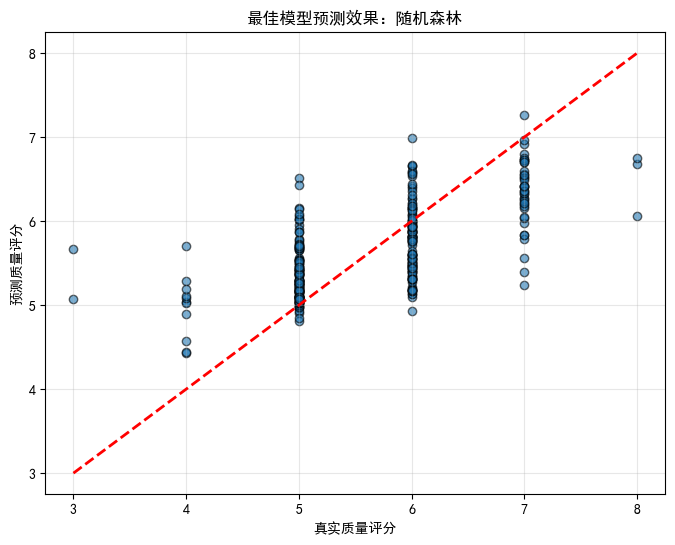

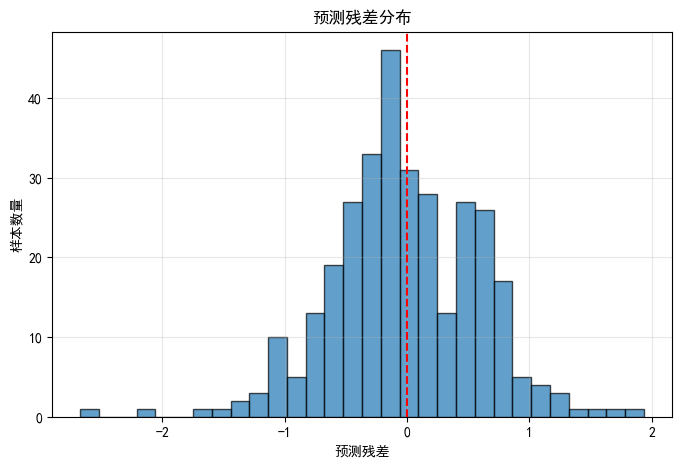


6.4 单一特征模拟拟合分析


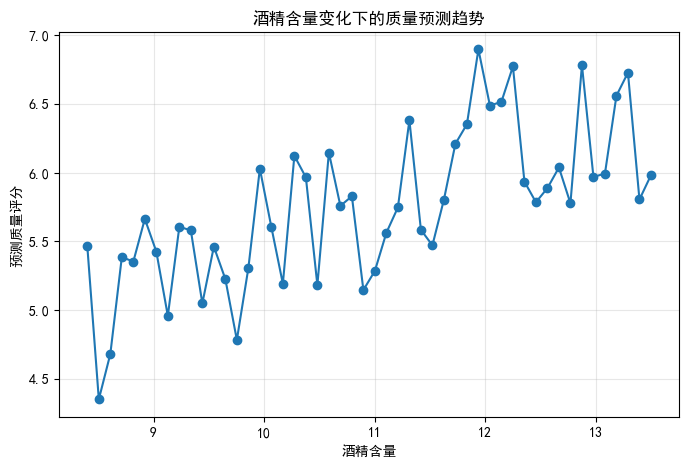

6.4 复合特征模拟拟合分析


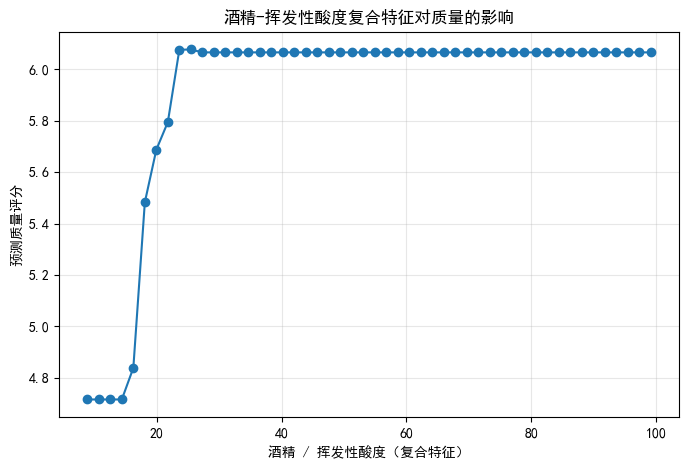

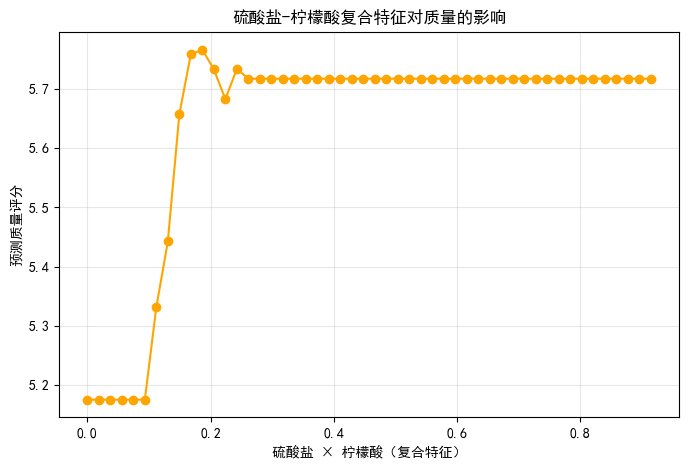


6.5 保存模型与结果
模型与评估结果已保存

✅ 模型训练与结果展示完成


In [7]:
# ==================== 第六阶段：模型训练与结果展示 ====================
print("\n" + "="*60)
print("6. 模型训练与结果展示")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# ==================== 6.1 数据拆分 ====================
print("\n6.1 数据拆分")

features = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'density',
    'fixed acidity'
]

X = df[features]
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")

# ==================== 6.2 模型选择与训练 ====================
print("\n6.2 模型训练")
print("-" * 60)

# 模型名称映射到中文
model_names_cn = {
    "LinearRegression": "线性回归",
    "RidgeRegression": "岭回归",
    "RandomForest": "随机森林",
    "GradientBoosting": "梯度提升树"
}

models = {
    "LinearRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "RidgeRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=8
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []

# 打印表头
print(f"{'模型名称':<10} {'RMSE':<12} {'MAE':<12} {'R²':<10}")
print("-" * 60)

for name_en, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 获取中文模型名称
    name_cn = model_names_cn.get(name_en, name_en)
    results.append([name_cn, rmse, mae, r2])

    # 格式化输出，每列对齐
    print(f"{name_cn:<10} {rmse:<12.3f} {mae:<12.3f} {r2:<10.3f}")

print("-" * 60)

results_df = pd.DataFrame(
    results, columns=['模型', 'RMSE', 'MAE', 'R2']
)

# 总结最佳模型
best_model_idx = results_df['R2'].idxmax()
best_model_cn = results_df.loc[best_model_idx, '模型']
best_r2 = results_df.loc[best_model_idx, 'R2']
best_rmse = results_df.loc[best_model_idx, 'RMSE']

print(f"\n🔍 模型性能总结:")
print("=" * 50)
print(f"最佳模型: {best_model_cn}")
print(f"最佳R²得分: {best_r2:.3f}")
print(f"最佳RMSE: {best_rmse:.3f}")
print("=" * 50)

# 获取最佳模型对应的英文名称
best_model_name_en = None
for name_en, name_cn in model_names_cn.items():
    if name_cn == best_model_cn:
        best_model_name_en = name_en
        break

best_model = models[best_model_name_en]

# ==================== 6.3 模型效果可视化 ====================
print("\n6.3 可视化模型效果")

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, edgecolor='black')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('真实质量评分')
plt.ylabel('预测质量评分')
plt.title(f'最佳模型预测效果：{best_model_cn}')
plt.grid(True, alpha=0.3)
plt.show()

# 残差分布
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('预测残差')
plt.ylabel('样本数量')
plt.title('预测残差分布')
plt.grid(True, alpha=0.3)
plt.show()

# ==================== 6.4 复合特征模拟拟合分析 ====================
import numpy as np
import matplotlib.pyplot as plt

print("\n6.4 单一特征模拟拟合分析")

alcohol_range = np.linspace(df['alcohol'].min(), df['alcohol'].max(), 50)

sim_data = X_test.copy()
sim_data = sim_data.iloc[:50].copy()

for i, val in enumerate(alcohol_range):
    sim_data.iloc[i % len(sim_data), sim_data.columns.get_loc('alcohol')] = val

sim_pred = best_model.predict(sim_data)

plt.figure(figsize=(8, 5))
plt.plot(alcohol_range, sim_pred[:50], '-o')
plt.xlabel('酒精含量')
plt.ylabel('预测质量评分')
plt.title('酒精含量变化下的质量预测趋势')
plt.grid(True, alpha=0.3)
plt.show()

print("6.4 复合特征模拟拟合分析")

# 使用测试集均值作为"基准样本"
base_sample = X_test.mean().to_frame().T

# ---------- 复合特征 1：酒精 / 挥发性酸度 ----------
ratio_range = np.linspace(
    (df['alcohol'] / df['volatile acidity']).min(),
    (df['alcohol'] / df['volatile acidity']).max(),
    50
)

pred_quality_ratio = []

for ratio in ratio_range:
    sample = base_sample.copy()
    sample['alcohol'] = ratio * sample['volatile acidity']
    pred_quality_ratio.append(best_model.predict(sample)[0])

plt.figure(figsize=(8, 5))
plt.plot(ratio_range, pred_quality_ratio, marker='o')
plt.xlabel('酒精 / 挥发性酸度（复合特征）')
plt.ylabel('预测质量评分')
plt.title('酒精-挥发性酸度复合特征对质量的影响')
plt.grid(alpha=0.3)
plt.show()


# ---------- 复合特征 2：硫酸盐 × 柠檬酸 ----------
product_range = np.linspace(
    (df['sulphates'] * df['citric acid']).min(),
    (df['sulphates'] * df['citric acid']).max(),
    50
)

pred_quality_product = []

for val in product_range:
    sample = base_sample.copy()
    sample['sulphates'] = val / sample['citric acid']
    pred_quality_product.append(best_model.predict(sample)[0])

plt.figure(figsize=(8, 5))
plt.plot(product_range, pred_quality_product, marker='o', color='orange')
plt.xlabel('硫酸盐 × 柠檬酸（复合特征）')
plt.ylabel('预测质量评分')
plt.title('硫酸盐-柠檬酸复合特征对质量的影响')
plt.grid(alpha=0.3)
plt.show()


# ==================== 6.5 保存模型与结果 ====================
print("\n6.5 保存模型与结果")

joblib.dump(best_model, 'wine_quality_best_model.pkl')
results_df.to_csv('model_evaluation_results.csv', index=False)

print("模型与评估结果已保存")

print("\n" + "="*60)
print("✅ 模型训练与结果展示完成")
print("="*60)